In [4]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import os
import scienceplots

# Apply SciencePlots style for ACL-quality publication figures
# Using 'science' with 'ieee' for proper column widths and professional styling
plt.style.use(['science', 'ieee', 'grid', 'no-latex'])  # no-latex for faster rendering, remove if you have LaTeX
# Alternative if you have LaTeX installed: plt.style.use(['science', 'ieee', 'grid'])

# Set default figure parameters for publication quality
plt.rcParams.update({
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.1,
    'font.size': 18,
    'axes.labelsize': 20,
    'axes.titlesize': 24,
    'xtick.labelsize': 18,
    'ytick.labelsize': 18,
    'legend.fontsize': 18,
    'legend.title_fontsize': 20,
    'figure.titlesize': 26,
    'font.family': 'Arial',
})

# ============================================================================
# UNIFIED AESTHETICS CONFIGURATION FOR ALL PLOTS
# ============================================================================

# Color scheme - Paul Tol's colorblind-safe palette
PLOT_COLORS = {
    "4B": "#4477AA",      # Blue - colorblind safe
    "8B": "#CC6677",      # Red/Pink - colorblind safe
    "base": "#CC6677",    # Base color for single-color plots
}

# Unified styling constants
STYLE = {
    # Grid
    'grid_linestyle': '--',
    'grid_alpha': 0.4,
    'grid_linewidth': 0.5,
    
    # Spines
    'spine_linewidth': 0.5,
    'hide_top': True,
    'hide_right': True,
    
    # Bars
    'bar_edgecolor': 'black',
    'bar_linewidth': 0.5,
    'bar_alpha': 0.9,
    'bar_width': 0.75,
    
    # Text labels
    'value_label_fontsize': 20,
    'title_fontsize': 32,
    'title_fontweight': 'bold',
    'title_pad': 10,
    'axis_label_fontsize': 32,
    'axis_label_fontweight': 'medium',
    'tick_label_fontsize': 28,
    
    # Legend
    'legend_fontsize': 22,
    'legend_frameon': True,
    'legend_fancybox': False,
    'legend_shadow': False,
    'legend_framealpha': 1.0,
    'legend_edgecolor': 'black',
    'legend_frame_linewidth': 0.5,
    'legend_bbox_to_anchor': (0.5, 1.02),
    
    # Figure
    'fig_dpi': 300,
    'fig_facecolor': 'white',
    'fig_tight_rect': [0, 0, 1, 0.96],
    
    # Heatmap
    'heatmap_text_fontsize': 20,  # Increased for better readability
    'heatmap_text_fontweight': 'medium',
    'heatmap_cbar_fontsize': 18,
    'heatmap_cbar_label_fontsize': 18,
    'heatmap_cbar_tick_fontsize': 16,
    'heatmap_cbar_tick_width': 0.5,
    'heatmap_cbar_tick_length': 3,
    'heatmap_cbar_outline_linewidth': 0.5,
    'heatmap_xlabel_fontsize': 22,  # Increased for T_max label
}

def apply_axis_styling(ax):
    """Apply unified axis styling to any axis"""
    ax.yaxis.grid(True, linestyle=STYLE['grid_linestyle'], 
                  alpha=STYLE['grid_alpha'], linewidth=STYLE['grid_linewidth'])
    ax.set_axisbelow(True)
    if STYLE['hide_top']:
        ax.spines['top'].set_visible(False)
    if STYLE['hide_right']:
        ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(STYLE['spine_linewidth'])
    ax.spines['bottom'].set_linewidth(STYLE['spine_linewidth'])

def apply_legend_styling(legend):
    """Apply unified legend styling"""
    legend.get_frame().set_linewidth(STYLE['legend_frame_linewidth'])


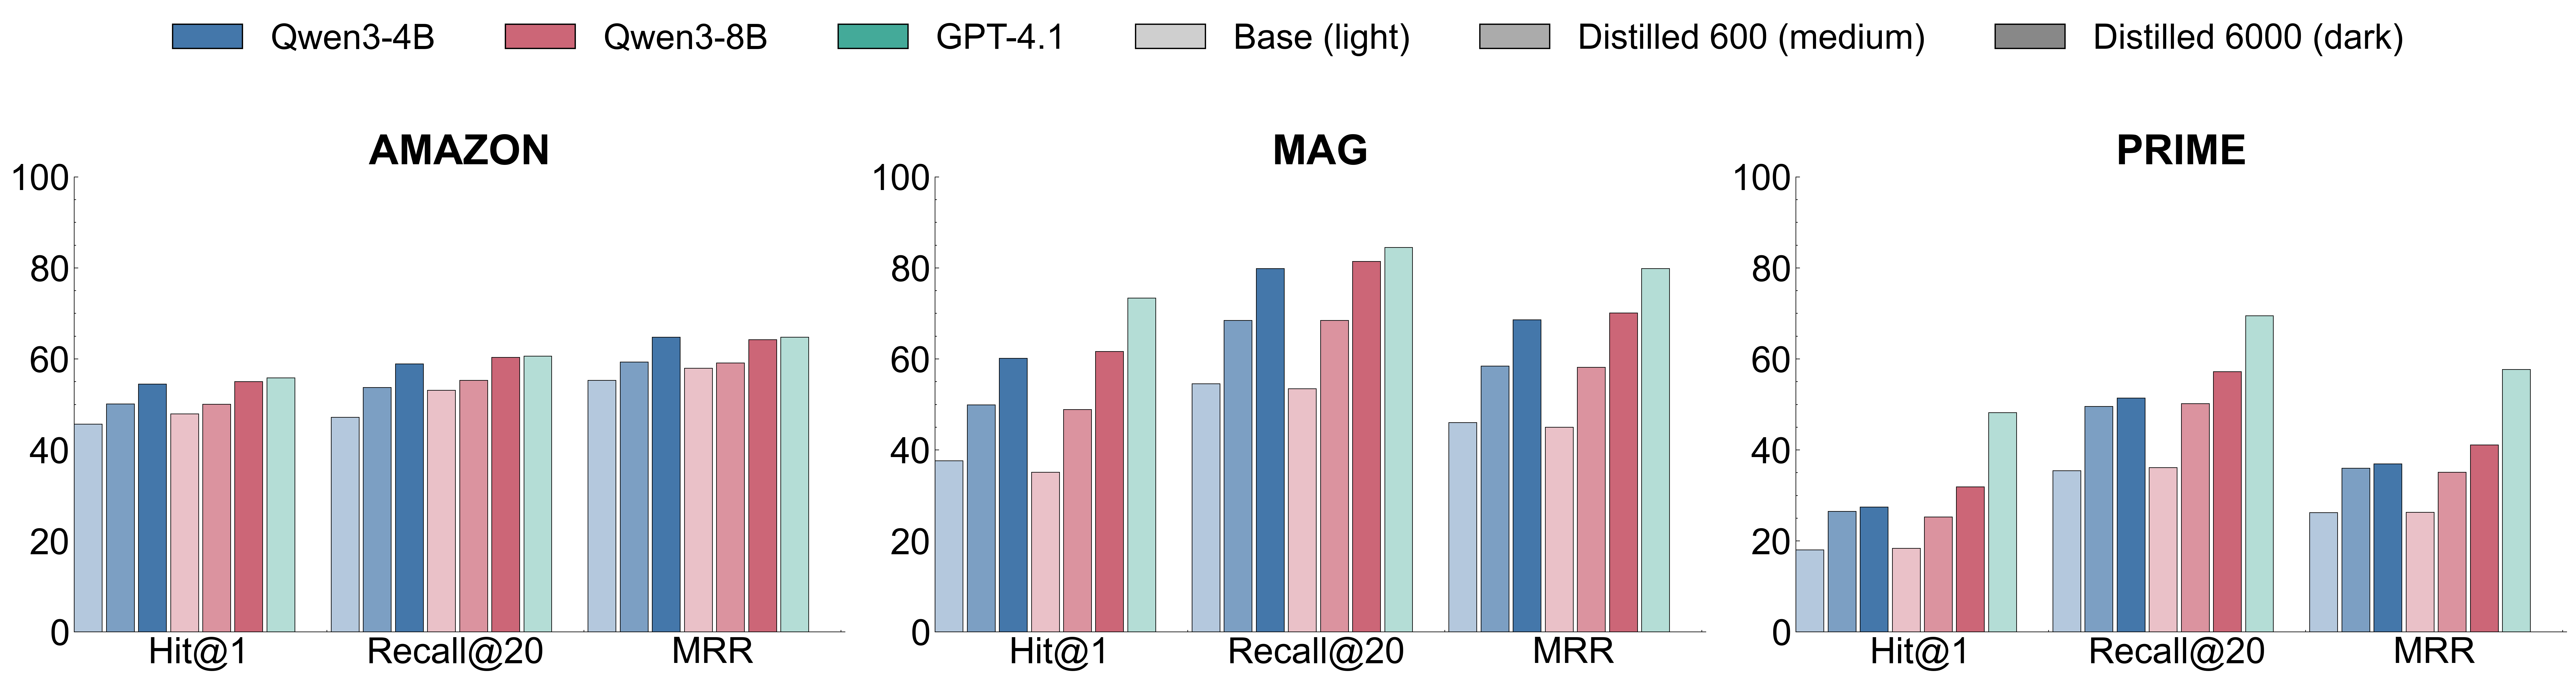

In [5]:
def third_figure():
    split = "test"

    graph_names = ["amazon", "mag", "prime"]
    metric_names = [
        "Hit@1",
        # "Hit@5",
        "Recall@20",
        "MRR",
    ]

    # Flat list of all models in order: 4B, 4B 600, 4B 6000, 8B, 8B 600, 8B 6000, GPT-4.1
    model_names = [
        "Qwen3-4B base",
        "Qwen3-4B distilled on 600 trajectories",
        "Qwen3-4B distilled on 6000 trajectories",
        "Qwen3-8B base",
        "Qwen3-8B distilled on 600 trajectories",
        "Qwen3-8B distilled on 6000 trajectories",
        "ChatGPT 4.1",
    ]

    # Data: graph_name -> model_name -> metrics dict
    # Values from table (converted from percentages to decimals)
    # Table structure: Amazon (Hit@1, Recall@20, MRR, Hit@5), MAG (Hit@1, Recall@20, MRR, Hit@5), Prime (Hit@1, Recall@20, MRR, Hit@5)
    _data = {
        "amazon": {
            "Qwen3-4B base": {"Hit@1": 0.4569, "Hit@5": 0.6746, "Recall@20": 0.4717, "MRR": 0.5526},
            "Qwen3-4B distilled on 600 trajectories": {
                "Hit@1": 0.5010,
                "Hit@5": 0.7126,
                "Recall@20": 0.5373,
                "MRR": 0.5932,
            },
            "Qwen3-8B base": {"Hit@1": 0.4795, "Hit@5": 0.7003, "Recall@20": 0.5310, "MRR": 0.5795},
            "Qwen3-8B distilled on 600 trajectories": {
                "Hit@1": 0.5006,
                "Hit@5": 0.7007,
                "Recall@20": 0.5529,
                "MRR": 0.5913,
            },
            "Qwen3-4B distilled on 6000 trajectories": {
                "Hit@1": 0.5446,
                "Hit@5": 0.7466,
                "Recall@20": 0.5891,
                "MRR": 0.6478,
            },
            "Qwen3-8B distilled on 6000 trajectories": {
                "Hit@1": 0.5499,
                "Hit@5": 0.7435,
                "Recall@20": 0.6031,
                "MRR": 0.6424,
            },
            "ChatGPT 4.1": {"Hit@1": 0.5582, "Hit@5": 0.7580, "Recall@20": 0.6061, "MRR": 0.6477},
        },
        "mag": {
            "Qwen3-4B base": {"Hit@1": 0.3764, "Hit@5": 0.5656, "Recall@20": 0.5454, "MRR": 0.4601},
            "Qwen3-4B distilled on 600 trajectories": {
                "Hit@1": 0.4990,
                "Hit@5": 0.6921,
                "Recall@20": 0.6847,
                "MRR": 0.5843,
            },
            "Qwen3-8B base": {"Hit@1": 0.3509, "Hit@5": 0.5702, "Recall@20": 0.5342, "MRR": 0.4496},
            "Qwen3-8B distilled on 600 trajectories": {
                "Hit@1": 0.4889,
                "Hit@5": 0.6941,
                "Recall@20": 0.6848,
                "MRR": 0.5813,
            },
            "Qwen3-4B distilled on 6000 trajectories": {
                "Hit@1": 0.6016,
                "Hit@5": 0.7879,
                "Recall@20": 0.7988,
                "MRR": 0.6859,
            },
            "Qwen3-8B distilled on 6000 trajectories": {
                "Hit@1": 0.6166,
                "Hit@5": 0.8041,
                "Recall@20": 0.8139,
                "MRR": 0.7009,
            },
            "ChatGPT 4.1": {"Hit@1": 0.7340, "Hit@5": 0.8792, "Recall@20": 0.8447, "MRR": 0.7987},
        },
        "prime": {
            "Qwen3-4B base": {"Hit@1": 0.1802, "Hit@5": 0.3700, "Recall@20": 0.3543, "MRR": 0.2620},
            "Qwen3-4B distilled on 600 trajectories": {
                "Hit@1": 0.2652,
                "Hit@5": 0.4727,
                "Recall@20": 0.4954,
                "MRR": 0.3601,
            },
            "Qwen3-8B base": {"Hit@1": 0.1837, "Hit@5": 0.3641, "Recall@20": 0.3613, "MRR": 0.2628},
            "Qwen3-8B distilled on 600 trajectories": {
                "Hit@1": 0.2524,
                "Hit@5": 0.4720,
                "Recall@20": 0.5016,
                "MRR": 0.3508,
            },
            "Qwen3-4B distilled on 6000 trajectories": {
                "Hit@1": 0.2746,
                "Hit@5": 0.4915,
                "Recall@20": 0.5140,
                "MRR": 0.3695,
            },
            "Qwen3-8B distilled on 6000 trajectories": {
                "Hit@1": 0.3187,
                "Hit@5": 0.5110,
                "Recall@20": 0.5722,
                "MRR": 0.4108,
            },
            "ChatGPT 4.1": {"Hit@1": 0.4820, "Hit@5": 0.6957, "Recall@20": 0.6946, "MRR": 0.5768},
        },
    }

    # Helper function to lighten a hex color
    def _lighten_color(hex_color, factor):
        """Lighten a hex color by blending with white. factor=0 is original, factor=1 is white."""
        hex_color = hex_color.lstrip("#")
        r, g, b = int(hex_color[0:2], 16), int(hex_color[2:4], 16), int(hex_color[4:6], 16)
        r = int(r + (255 - r) * factor)
        g = int(g + (255 - g) * factor)
        b = int(b + (255 - b) * factor)
        return f"#{r:02x}{g:02x}{b:02x}"

    # Base colors
    _blue_full = "#4477AA"
    _red_full = "#CC6677"
    _teal_full = "#44AA99"

    # Lighter versions (base = lightest, distilled 600 = medium, distilled 6000 = full)
    _blue_light = _lighten_color(_blue_full, 0.6)  # 60% toward white for base
    _blue_medium = _lighten_color(_blue_full, 0.3)  # 30% toward white for distilled 600
    _red_light = _lighten_color(_red_full, 0.6)  # 60% toward white for base
    _red_medium = _lighten_color(_red_full, 0.3)  # 30% toward white for distilled 600
    _teal_light = _lighten_color(_teal_full, 0.6)  # 60% toward white for GPT base

    # Color scheme using lighter versions instead of opacity
    # 4B: light (base), medium (600), dark (6000)
    # 8B: light (base), medium (600), dark (6000)
    _model_colors = {
        "Qwen3-4B base": _blue_light,  # Light blue (4B base)
        "Qwen3-4B distilled on 600 trajectories": _blue_medium,  # Medium blue (4B 600)
        "Qwen3-8B base": _red_light,  # Light red/pink (8B base)
        "Qwen3-8B distilled on 600 trajectories": _red_medium,  # Medium red/pink (8B 600)
        "Qwen3-4B distilled on 6000 trajectories": _blue_full,  # Full blue (4B 6000, dark)
        "Qwen3-8B distilled on 6000 trajectories": _red_full,  # Full red/pink (8B 6000, dark)
        "ChatGPT 4.1": _teal_light,  # Light teal (GPT-4.1)
    }

    # Hatch patterns for distinction
    _model_hatches = {
        "Qwen3-4B base": None,
        "Qwen3-4B distilled on 600 trajectories": None,
        "Qwen3-8B base": None,
        "Qwen3-8B distilled on 600 trajectories": None,
        "Qwen3-4B distilled on 6000 trajectories": None,
        "Qwen3-8B distilled on 6000 trajectories": None,
        "ChatGPT 4.1": None,
    }

    # Short labels for x-axis
    _model_short_labels = {
        "Qwen3-4B base": "4B",
        "Qwen3-4B distilled on 600 trajectories": "4B",
        "Qwen3-8B base": "8B",
        "Qwen3-8B distilled on 600 trajectories": "8B",
        "Qwen3-4B distilled on 6000 trajectories": "4B",
        "Qwen3-8B distilled on 6000 trajectories": "8B",
        "ChatGPT 4.1": "GPT-4.1",
    }

    # Calculate x positions - simple sequential layout without groups
    bar_width = 1.0  # Increased to make bars wider
    bar_gap = 0.15  # Gap between bars

    # Calculate positions for each model sequentially
    x_positions = []
    current_x = 0
    for i, model in enumerate(model_names):
        x_positions.append(current_x)
        current_x += bar_width + bar_gap

    x_positions = np.array(x_positions)

    # Figure: side by side (columns = graphs), x-axis = metrics
    # Make the figure taller: increase the height from 6 to (for example) 8
    fig, axes = plt.subplots(1, len(graph_names), figsize=(28, 7), sharey=True)
    if len(graph_names) == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    # Calculate x positions for metrics with gaps between them
    metric_gap = 1.0  # Gap between metric groups
    metric_group_width = x_positions[-1] + bar_width + 0.3  # Width of one metric group (all models)

    metric_x_offsets = []
    current_metric_x = 0
    for metric_idx in range(len(metric_names)):
        metric_x_offsets.append(current_metric_x)
        current_metric_x += metric_group_width + metric_gap

    for col_idx, graph_name in enumerate(graph_names):
        ax = axes[col_idx]

        # Apply unified axis styling
        apply_axis_styling(ax)
        # Remove the grid
        ax.grid(False)

        # Drop axis ticks and spines on top and right
        ax.tick_params(top=False, right=False)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        # Remove little ticks on top and right
        ax.tick_params(axis='x', which='both', top=False)
        ax.tick_params(axis='y', which='both', right=False)

        # Draw bars for each metric
        for metric_idx, metric in enumerate(metric_names):
            metric_x_base = metric_x_offsets[metric_idx]

            values = [_data[graph_name][model][metric] * 100 for model in model_names]  # Convert to percentages
            colors = [_model_colors[model] for model in model_names]
            hatches = [_model_hatches[model] for model in model_names]

            # Draw bars individually for this metric
            for i, (x_pos_base, val, color, hatch) in enumerate(
                zip(x_positions, values, colors, hatches)
            ):
                x_pos = metric_x_base + x_pos_base
                bar = ax.bar(
                    x_pos,
                    val,
                    bar_width,
                    color=color,
                    edgecolor=STYLE["bar_edgecolor"],
                    linewidth=STYLE["bar_linewidth"],
                    hatch=hatch,
                )

        ax.set_ylim(0, 100)
        # Set y-ticks from 0 to 100 - show on all graphs
        ax.set_yticks(np.arange(0, 101, 20))
        ax.set_yticklabels(
            [f"{int(tick)}" for tick in np.arange(0, 101, 20)],
            fontsize=STYLE["tick_label_fontsize"],
        )
        # Explicitly show y-ticks on all subplots
        ax.tick_params(
            axis="y", which="major", labelsize=STYLE["tick_label_fontsize"], labelleft=True
        )

        # Set x-axis limits to properly frame all metrics
        ax.set_xlim(-0.5, metric_x_offsets[-1] + metric_group_width + 0.5)

        # X-axis: show on all columns (since each column represents a graph)
        # Calculate metric centers for x-axis labels
        metric_centers = [offset + (x_positions[-1] + bar_width) / 2 for offset in metric_x_offsets]

        # Main x-axis labels: metric names at the center of each metric group
        ax.set_xticks(metric_centers)
        ax.set_xticklabels(
            metric_names, rotation=0, ha="center", fontsize=STYLE["tick_label_fontsize"]
        )

        # Y-axis label: only on first column (left side)
        # if col_idx == 0:
        #     ax.set_ylabel(
        #         "Retrieval metric (%)",
        #         fontsize=STYLE["axis_label_fontsize"],
        #         fontweight=STYLE["axis_label_fontweight"],
        #     )

        # Title: graph name on top of each column
        ax.set_title(
            graph_name.upper(),
            fontsize=STYLE["title_fontsize"],
            fontweight=STYLE["title_fontweight"],
            pad=STYLE["title_pad"],
        )

    # Create legend handles manually - show by model size and type
    _legend_labels = [
        "Qwen3-4B",
        "Qwen3-8B",
        "GPT-4.1",
    ]
    _legend_colors_full = [_blue_full, _red_full, _teal_full]

    _legend_handles = [
        plt.Rectangle((0, 0), 1, 1, facecolor=color, edgecolor=STYLE["bar_edgecolor"])
        for color in _legend_colors_full
    ]

    # Add shade legend with corresponding colors
    # 4B: light (base), medium (600), dark (6000)
    # 8B: light (base), medium (600), dark (6000)
    _hatch_labels = ["Base (light)", "Distilled 600 (medium)", "Distilled 6000 (dark)"]
    _hatch_patterns = [None, None, None]
    _hatch_legend_colors = [
        _lighten_color("#888888", 0.6),  # Light gray for base
        _lighten_color("#888888", 0.3),  # Medium gray for distilled 600
        "#888888",  # Full gray for distilled 6000
    ]
    _hatch_handles = [
        plt.Rectangle((0, 0), 1, 1, facecolor=color, edgecolor=STYLE["bar_edgecolor"], hatch=hatch)
        for hatch, color in zip(_hatch_patterns, _hatch_legend_colors)
    ]

    # Combined legend
    all_handles = _legend_handles + _hatch_handles
    all_labels = _legend_labels + _hatch_labels

    legend = fig.legend(
        all_handles,
        all_labels,
        loc="upper center",
        ncol=6,  # All items in one row
        bbox_to_anchor=(0.5, 1.08),  # Higher to accommodate larger legend
        frameon=False,   # Drop the legend frame
        fancybox=STYLE["legend_fancybox"],
        shadow=STYLE["legend_shadow"],
        framealpha=STYLE["legend_framealpha"],
        edgecolor=STYLE["legend_edgecolor"],
        fontsize=STYLE["legend_fontsize"] + 5,  # Significantly increased font size for readability
        handlelength=2.0,  # Make legend handles even bigger
        handletextpad=0.8,  # More spacing between handle and text
        columnspacing=2.0,  # More spacing between columns
    )
    # Do not apply legend frame styling, frame is off

    fig.tight_layout(rect=[0, 0, 1, 0.90])  # Adjusted to accommodate larger legend
    os.makedirs("../data/figures", exist_ok=True)
    plt.savefig(
        f"../data/figures/fig-4-full_model_comparison_grid.pdf",
        bbox_inches="tight",
        facecolor=STYLE["fig_facecolor"],
    )
    plt.show()


third_figure()